### Import Library

In [73]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

### Read CSV File

In [74]:
df = pd.read_csv('../data/data.csv')

df_original = df.copy()
print(f"Original dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

Original dataset shape: (48842, 15)

First few rows:
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-State

### 1. Inspect dataset size, structure, and data types.
#### Dataset Size

In [75]:
print("Number of row and columns:", df.shape)
print("Column names:", df.columns.tolist())
print("Number of rows:", len(df))

Number of row and columns: (48842, 15)
Column names: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
Number of rows: 48842


In [76]:
print("Data Information:")
print("-" * 50)
print(df.info())

Data Information:
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       47879 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      47876 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48568 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB
None


##### Data Type

In [77]:
print("Numerical columns:")
numerical_data = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(numerical_data)

Numerical columns:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [78]:
print("Categorical columns:")
categorical_data = df.select_dtypes(include=['object']).columns.tolist()
print(categorical_data)

Categorical columns:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']


### Dataset Structure

In [79]:
print("Categorical:")
print(df[categorical_data].head())
print("Numerical:")
print(df[numerical_data].head())

Categorical:
          workclass  education      marital-status         occupation  \
0         State-gov  Bachelors       Never-married       Adm-clerical   
1  Self-emp-not-inc  Bachelors  Married-civ-spouse    Exec-managerial   
2           Private    HS-grad            Divorced  Handlers-cleaners   
3           Private       11th  Married-civ-spouse  Handlers-cleaners   
4           Private  Bachelors  Married-civ-spouse     Prof-specialty   

    relationship   race     sex native-country income  
0  Not-in-family  White    Male  United-States  <=50K  
1        Husband  White    Male  United-States  <=50K  
2  Not-in-family  White    Male  United-States  <=50K  
3        Husband  Black    Male  United-States  <=50K  
4           Wife  Black  Female           Cuba  <=50K  
Numerical:
   age  fnlwgt  education-num  capital-gain  capital-loss  hours-per-week
0   39   77516             13          2174             0              40
1   50   83311             13             0          

# DATA CLEANING PROCESS

## Step 1: Handle Missing Values

In [80]:
# Replace '?' with NaN for proper handling
df = df.replace('?', np.nan)
df = df.replace(' ?', np.nan)

# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())
print(f"\nPercentage of missing values:")
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent[missing_percent > 0].round(2))

Missing values before cleaning:
age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64

Percentage of missing values:
workclass         5.73
occupation        5.75
native-country    1.75
dtype: float64
age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64

Percentage of missing values:
workclass         5.73
occupation        5.75
native-country    1.75
dtype: float64


In [81]:
# Strategy: For categorical variables with missing values, we'll use mode imputation
# or drop rows if missing percentage is very low

# Check which columns have missing values
cols_with_missing = df.columns[df.isnull().any()].tolist()
print(f"Columns with missing values: {cols_with_missing}")

# For this dataset, we'll drop rows with missing values since the percentage is typically low (<5%)
rows_before = len(df)
df = df.dropna()
rows_after = len(df)
print(f"\nRows removed: {rows_before - rows_after} ({((rows_before - rows_after)/rows_before)*100:.2f}%)")
print(f"Remaining rows: {rows_after}")

Columns with missing values: ['workclass', 'occupation', 'native-country']

Rows removed: 3620 (7.41%)
Remaining rows: 45222


## Step 2: Remove Duplicates

In [82]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found.")

Number of duplicate rows: 28
Duplicates removed. New shape: (45194, 15)
Duplicates removed. New shape: (45194, 15)


## Step 3: Clean Text Data (Strip Whitespace)

In [83]:
categorical_cols = df.select_dtypes(include=['object']).columns

print("Cleaning text data (removing leading/trailing whitespaces and dots)...")
for col in categorical_cols:
    df[col] = df[col].str.strip()
    df[col] = df[col].str.rstrip('.')
    
print("Text data cleaned successfully!")
print("\nSample values after cleaning:")
print(df[categorical_cols].head())
print("\nUnique income values:", df['income'].unique())

Cleaning text data (removing leading/trailing whitespaces and dots)...
Text data cleaned successfully!

Sample values after cleaning:
          workclass  education      marital-status         occupation  \
0         State-gov  Bachelors       Never-married       Adm-clerical   
1  Self-emp-not-inc  Bachelors  Married-civ-spouse    Exec-managerial   
2           Private    HS-grad            Divorced  Handlers-cleaners   
3           Private       11th  Married-civ-spouse  Handlers-cleaners   
4           Private  Bachelors  Married-civ-spouse     Prof-specialty   

    relationship   race     sex native-country income  
0  Not-in-family  White    Male  United-States  <=50K  
1        Husband  White    Male  United-States  <=50K  
2  Not-in-family  White    Male  United-States  <=50K  
3        Husband  Black    Male  United-States  <=50K  
4           Wife  Black  Female           Cuba  <=50K  

Unique income values: <StringArray>
['<=50K', '>50K']
Length: 2, dtype: str
Text data clea

## Step 4: Validate Data Ranges and Business Logic

In [84]:
print("Checking data validity...")

invalid_age = df[(df['age'] < 17) | (df['age'] > 90)]
print(f"Invalid age records: {len(invalid_age)}")

invalid_hours = df[(df['hours-per-week'] < 1) | (df['hours-per-week'] > 100)]
print(f"Invalid hours-per-week records: {len(invalid_hours)}")

invalid_capital = df[(df['capital-gain'] < 0) | (df['capital-loss'] < 0)]
print(f"Invalid capital records: {len(invalid_capital)}")

invalid_edu = df[(df['education-num'] < 1) | (df['education-num'] > 16)]
print(f"Invalid education-num records: {len(invalid_edu)}")

initial_rows = len(df)
df = df[(df['age'] >= 17) & (df['age'] <= 90)]
df = df[(df['hours-per-week'] >= 1) & (df['hours-per-week'] <= 100)]
df = df[(df['capital-gain'] >= 0) & (df['capital-loss'] >= 0)]
df = df[(df['education-num'] >= 1) & (df['education-num'] <= 16)]
print(f"\nRows removed due to invalid values: {initial_rows - len(df)}")
print(f"Remaining rows: {len(df)}")

Checking data validity...
Invalid age records: 0
Invalid hours-per-week records: 0
Invalid capital records: 0
Invalid education-num records: 0

Rows removed due to invalid values: 0
Remaining rows: 45194


## Step 5: Handle Outliers (IQR Method)

In [85]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Numerical columns: {numerical_cols}")

# Calculate outliers using IQR method
def detect_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("\nOutlier Analysis:")# Identify numerical columns for outlier detection

print("-" * 70)
for col in numerical_cols:
    n_outliers, lower, upper = detect_outliers_iqr(df, col)
    print(f"{col}: {n_outliers} outliers (Valid range: {lower:.2f} to {upper:.2f})")

Numerical columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Outlier Analysis:
----------------------------------------------------------------------
age: 268 outliers (Valid range: -0.50 to 75.50)
fnlwgt: 1332 outliers (Valid range: -63373.88 to 418669.12)
education-num: 291 outliers (Valid range: 3.00 to 19.00)
capital-gain: 3790 outliers (Valid range: 0.00 to 0.00)
capital-loss: 2140 outliers (Valid range: 0.00 to 0.00)
hours-per-week: 11892 outliers (Valid range: 32.50 to 52.50)


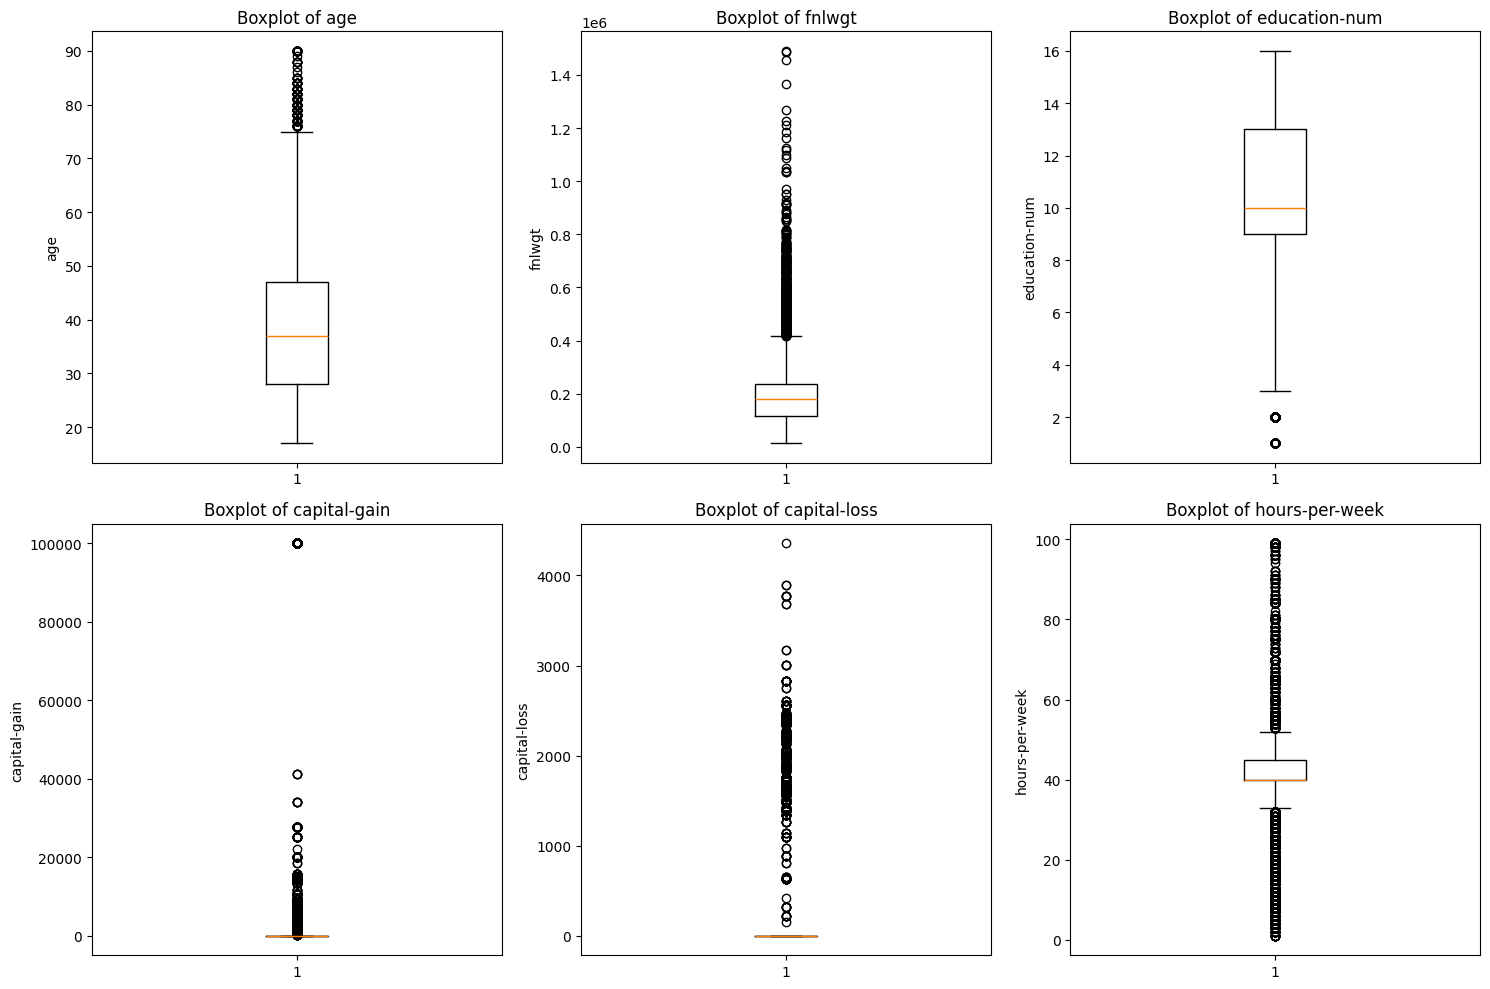

In [86]:
# Visualize outliers with boxplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        axes[idx].boxplot(df[col].dropna())
        axes[idx].set_title(f'Boxplot of {col}')
        axes[idx].set_ylabel(col)

plt.tight_layout()
plt.show()

In [87]:
# Decision: Keep outliers for some columns as they represent valid data points
# For example: capital-gain, capital-loss, hours-per-week may have legitimate extreme values
# We'll only remove extreme outliers from age if any exist beyond our validation

print("Note: Outliers in capital-gain, capital-loss, and hours-per-week are kept")
print("as they represent legitimate extreme values in the census data.")
print(f"\nCurrent dataset shape: {df.shape}")

Note: Outliers in capital-gain, capital-loss, and hours-per-week are kept
as they represent legitimate extreme values in the census data.

Current dataset shape: (45194, 15)


## Step 6: Standardize Categorical Values

In [88]:
# Check unique values in each categorical column
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Unique values in categorical columns:")
print("-" * 70)
for col in categorical_cols:
    unique_vals = df[col].unique()
    print(f"\n{col} ({len(unique_vals)} unique values):")
    print(unique_vals)

Unique values in categorical columns:
----------------------------------------------------------------------

workclass (7 unique values):
<StringArray>
[       'State-gov', 'Self-emp-not-inc',          'Private',
      'Federal-gov',        'Local-gov',     'Self-emp-inc',
      'Without-pay']
Length: 7, dtype: str

education (16 unique values):
<StringArray>
[   'Bachelors',      'HS-grad',         '11th',      'Masters',
          '9th', 'Some-college',   'Assoc-acdm',      '7th-8th',
    'Doctorate',    'Assoc-voc',  'Prof-school',      '5th-6th',
         '10th',    'Preschool',         '12th',      '1st-4th']
Length: 16, dtype: str

marital-status (7 unique values):
<StringArray>
[        'Never-married',    'Married-civ-spouse',              'Divorced',
 'Married-spouse-absent',             'Separated',     'Married-AF-spouse',
               'Widowed']
Length: 7, dtype: str

occupation (14 unique values):
<StringArray>
[     'Adm-clerical',   'Exec-managerial', 'Handlers-cleane

## Step 7: Handle Rare Categories

In [89]:
# Group rare categories (less than 1% frequency) into 'Other'
threshold = 0.01

print("Handling rare categories (frequency < 1%):")
print("-" * 70)

for col in categorical_cols:
    # Calculate frequency
    freq = df[col].value_counts(normalize=True)
    rare_categories = freq[freq < threshold].index.tolist()
    
    if len(rare_categories) > 0:
        print(f"\n{col}: {len(rare_categories)} rare categories found")
        print(f"Rare categories: {rare_categories}")
        # Replace rare categories with 'Other'
        df[col] = df[col].apply(lambda x: 'Other' if x in rare_categories else x)
        print(f"Replaced with 'Other'")
    else:
        print(f"\n{col}: No rare categories found")

Handling rare categories (frequency < 1%):
----------------------------------------------------------------------

workclass: 1 rare categories found
Rare categories: ['Without-pay']
Replaced with 'Other'

education: 3 rare categories found
Rare categories: ['5th-6th', '1st-4th', 'Preschool']
Replaced with 'Other'

marital-status: 1 rare categories found
Rare categories: ['Married-AF-spouse']


Replaced with 'Other'

occupation: 2 rare categories found
Rare categories: ['Priv-house-serv', 'Armed-Forces']
Replaced with 'Other'

relationship: No rare categories found

race: 2 rare categories found
Rare categories: ['Amer-Indian-Eskimo', 'Other']
Replaced with 'Other'

sex: No rare categories found

native-country: 39 rare categories found
Rare categories: ['Philippines', 'Germany', 'Puerto-Rico', 'Canada', 'India', 'El-Salvador', 'Cuba', 'England', 'China', 'Jamaica', 'South', 'Italy', 'Dominican-Republic', 'Japan', 'Guatemala', 'Vietnam', 'Columbia', 'Poland', 'Haiti', 'Portugal', 'Iran', 'Taiwan', 'Greece', 'Nicaragua', 'Peru', 'Ecuador', 'France', 'Ireland', 'Thailand', 'Hong', 'Cambodia', 'Trinadad&Tobago', 'Yugoslavia', 'Outlying-US(Guam-USVI-etc)', 'Laos', 'Scotland', 'Honduras', 'Hungary', 'Holand-Netherlands']
Replaced with 'Other'

income: No rare categories found
Replaced with 'Other'

relationship: No rare categories found

race: 2 rare categories found
Rare categori

## Step 8: Reset Index and Final Verification

In [90]:
# Reset index after all cleaning operations
df = df.reset_index(drop=True)

print("Final dataset verification:")
print("-" * 70)
print(f"Final shape: {df.shape}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Final dataset verification:
----------------------------------------------------------------------
Final shape: (45194, 15)

Data types:
age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str
dtype: object

Missing values: 0

Duplicate rows: 19

Duplicate rows: 19


In [91]:
# Display summary statistics
print("\nNumerical columns summary:")
print(df.describe())

print("\n" + "-" * 70)
print("Categorical columns summary:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Numerical columns summary:
                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  45194.000000  4.519400e+04   45194.000000  45194.000000  45194.000000   
mean      38.551755  1.897379e+05      10.119109   1102.112736     88.650308   
std       13.215806  1.056407e+05       2.552057   7508.705003    405.075515   
min       17.000000  1.349200e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.173922e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783120e+05      10.000000      0.000000      0.000000   
75%       47.000000  2.379030e+05      13.000000      0.000000      0.000000   
max       90.000000  1.490400e+06      16.000000  99999.000000   4356.000000   

       hours-per-week  
count    45194.000000  
mean        40.941209  
std         12.006449  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  

----------------------------------

## Step 9: Save Cleaned Dataset

In [92]:
df.to_csv('../data/data_cleaned.csv', index=False)
print("Cleaned dataset saved as 'data_cleaned.csv'")

print("\n" + "-" * 70)
print("DATA CLEANING REPORT")
print("-" * 70)
print(f"Original dataset size: {df_original.shape}")
print(f"Cleaned dataset size: {df.shape}")
print(f"Rows removed: {df_original.shape[0] - df.shape[0]} ({((df_original.shape[0] - df.shape[0])/df_original.shape[0])*100:.2f}%)")
print(f"Rows retained: {df.shape[0]} ({(df.shape[0]/df_original.shape[0])*100:.2f}%)")
print("\nCleaning operations performed:")
print("✓ Handled missing values (replaced '?' with NaN and removed)")
print("✓ Removed duplicate rows")
print("✓ Stripped whitespace from text data")
print("✓ Validated data ranges and business logic")
print("✓ Analyzed and documented outliers")
print("✓ Grouped rare categories (<1% frequency)")
print("✓ Reset index for clean indexing")
print("-" * 70)

Cleaned dataset saved as 'data_cleaned.csv'

----------------------------------------------------------------------
DATA CLEANING REPORT
----------------------------------------------------------------------
Original dataset size: (48842, 15)
Cleaned dataset size: (45194, 15)
Rows removed: 3648 (7.47%)
Rows retained: 45194 (92.53%)

Cleaning operations performed:
✓ Handled missing values (replaced '?' with NaN and removed)
✓ Removed duplicate rows
✓ Stripped whitespace from text data
✓ Validated data ranges and business logic
✓ Analyzed and documented outliers
✓ Grouped rare categories (<1% frequency)
✓ Reset index for clean indexing
----------------------------------------------------------------------


## Data Visualization After Cleaning

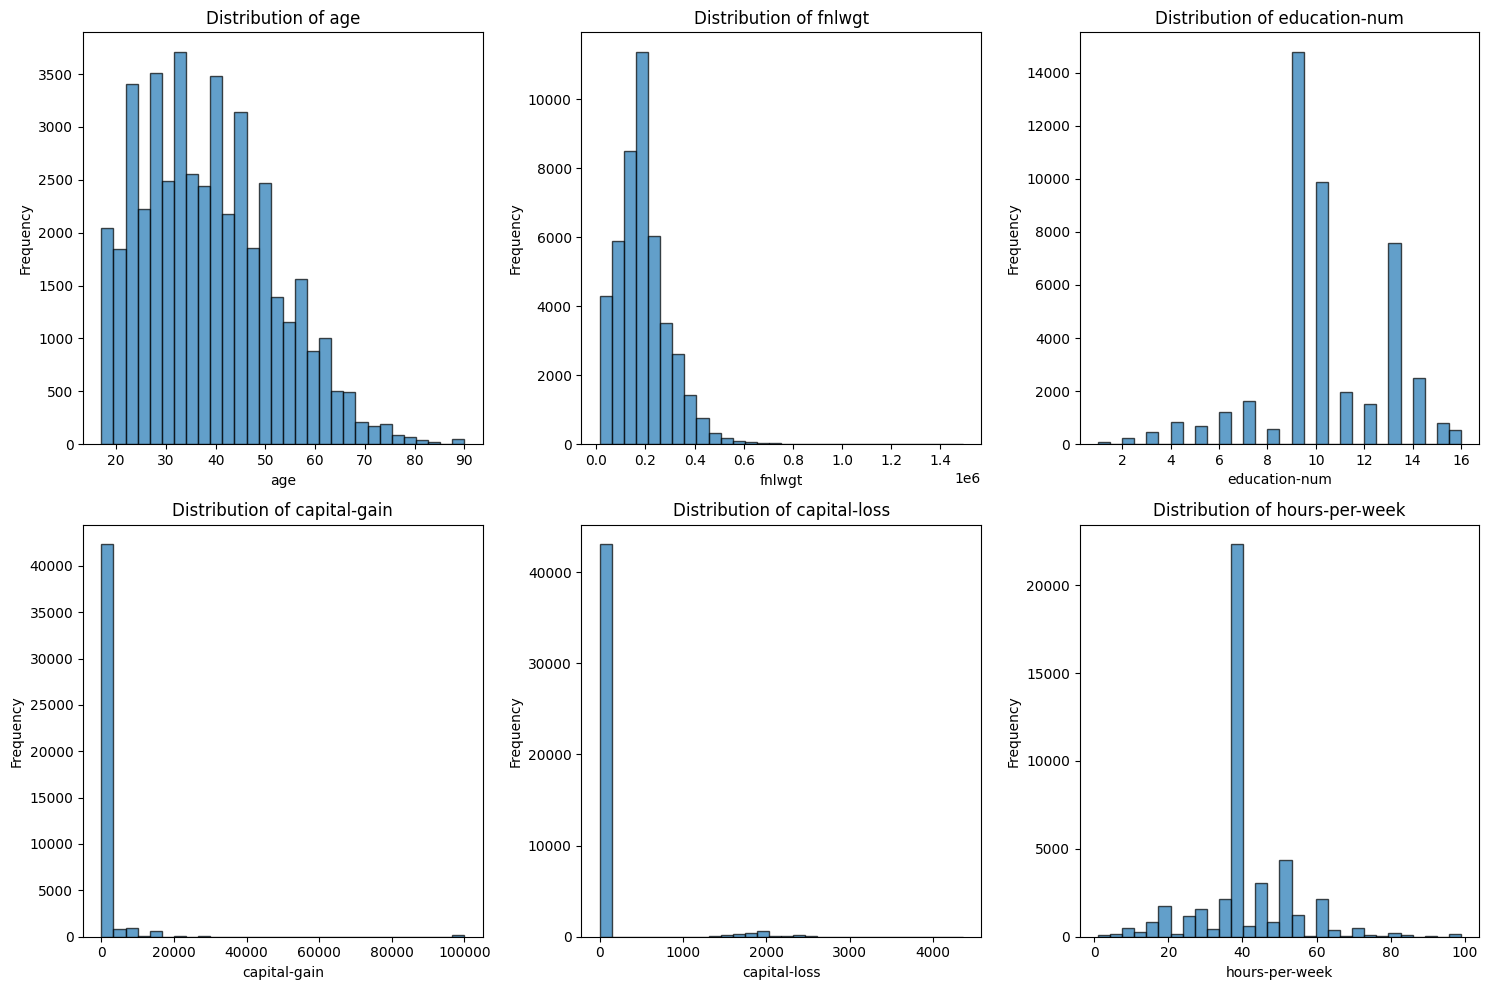

In [93]:
# Distribution of numerical features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution of {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

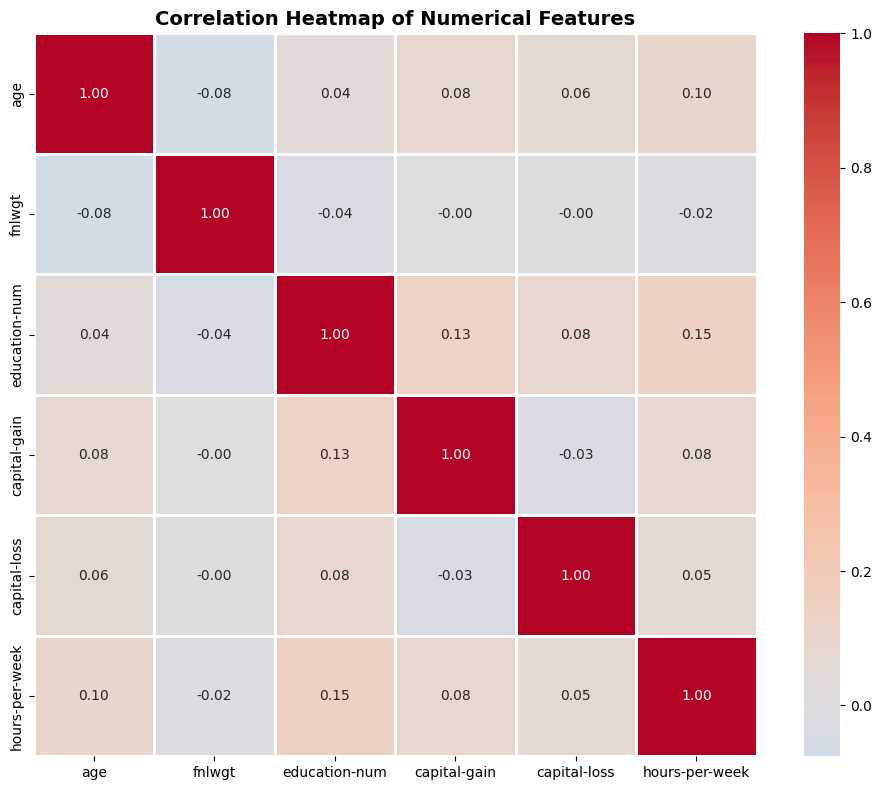

In [94]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

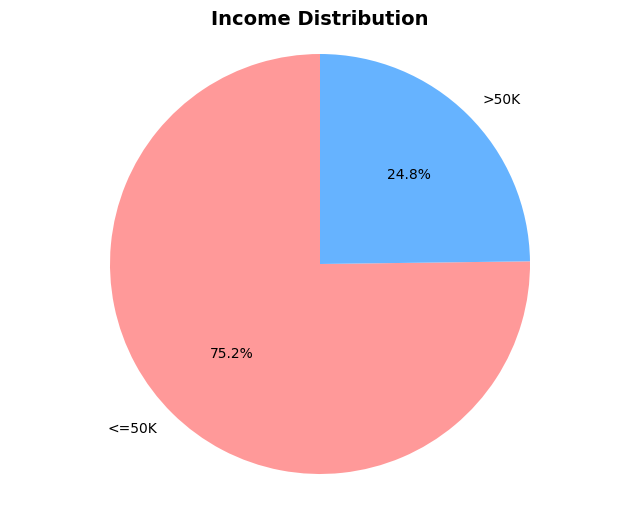

Income Distribution:
income
<=50K    33988
>50K     11206
Name: count, dtype: int64

Percentage:
income
<=50K    75.204673
>50K     24.795327
Name: proportion, dtype: float64


In [95]:
# Income distribution
plt.figure(figsize=(8, 6))
income_counts = df['income'].value_counts()
plt.pie(income_counts.values, labels=income_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title('Income Distribution', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

print("Income Distribution:")
print(income_counts)
print(f"\nPercentage:")
print(df['income'].value_counts(normalize=True) * 100)

# EXPLORATORY DATA ANALYSIS (EDA)

## 1. Salary Distribution Analysis

--------------------------------------------------
SALARY DISTRIBUTION ANALYSIS
--------------------------------------------------

Income Distribution:
<=50K: 33,988 records (75.20%)
>50K: 11,206 records (24.80%)

Class Imbalance Ratio: 3.03:1
This is a moderately imbalanced dataset


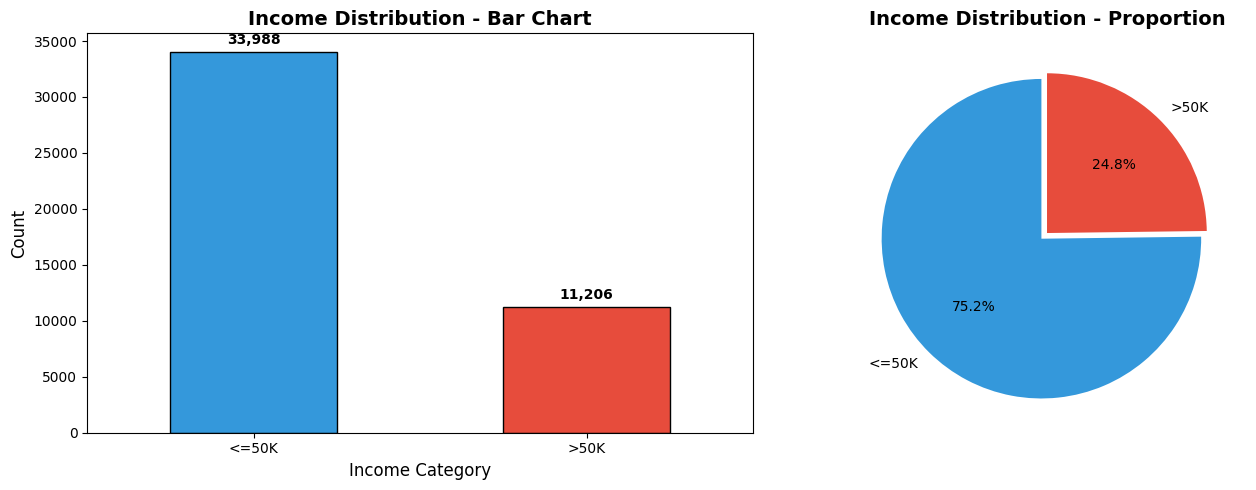

In [96]:
# Detailed salary distribution analysis
print("-" * 50)
print("SALARY DISTRIBUTION ANALYSIS")
print("-" * 50)

# Count and percentage
income_dist = df['income'].value_counts()
income_pct = df['income'].value_counts(normalize=True) * 100

print("\nIncome Distribution:")
for category, count in income_dist.items():
    pct = income_pct[category]
    print(f"{category}: {count:,} records ({pct:.2f}%)")

# Calculate imbalance ratio
max_class = income_dist.max()
min_class = income_dist.min()
imbalance_ratio = max_class / min_class
print(f"\nClass Imbalance Ratio: {imbalance_ratio:.2f}:1")
print(f"This is a {'balanced' if imbalance_ratio < 2 else 'moderately imbalanced' if imbalance_ratio < 5 else 'highly imbalanced'} dataset")

# Visualize with bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
income_dist.plot(kind='bar', ax=ax1, color=['#3498db', '#e74c3c'], edgecolor='black')
ax1.set_title('Income Distribution - Bar Chart', fontsize=14, fontweight='bold')
ax1.set_xlabel('Income Category', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
for i, v in enumerate(income_dist.values):
    ax1.text(i, v + 500, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart - dynamic explode based on number of categories
num_categories = len(income_dist)
explode_vals = [0.05] + [0] * (num_categories - 1)  # Explode only first slice
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12'][:num_categories]  # Dynamic colors

ax2.pie(income_dist.values, labels=income_dist.index, autopct='%1.1f%%',
        startangle=90, colors=colors, explode=explode_vals)
ax2.set_title('Income Distribution - Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Education Level vs Income Analysis

----------------------------------------------------------------------
EDUCATION LEVEL VS INCOME ANALYSIS
----------------------------------------------------------------------

Percentage earning >50K by education level:
education
Prof-school     75.414013
Doctorate       73.345588
Masters         55.431755
Bachelors       42.009253
Assoc-acdm      26.410086
Assoc-voc       25.740552
Some-college    20.111223
HS-grad         16.342965
12th             7.465278
10th             6.704824
7th-8th          6.690998
9th              5.621302
11th             5.497221
Other            4.194858
Name: >50K, dtype: float64


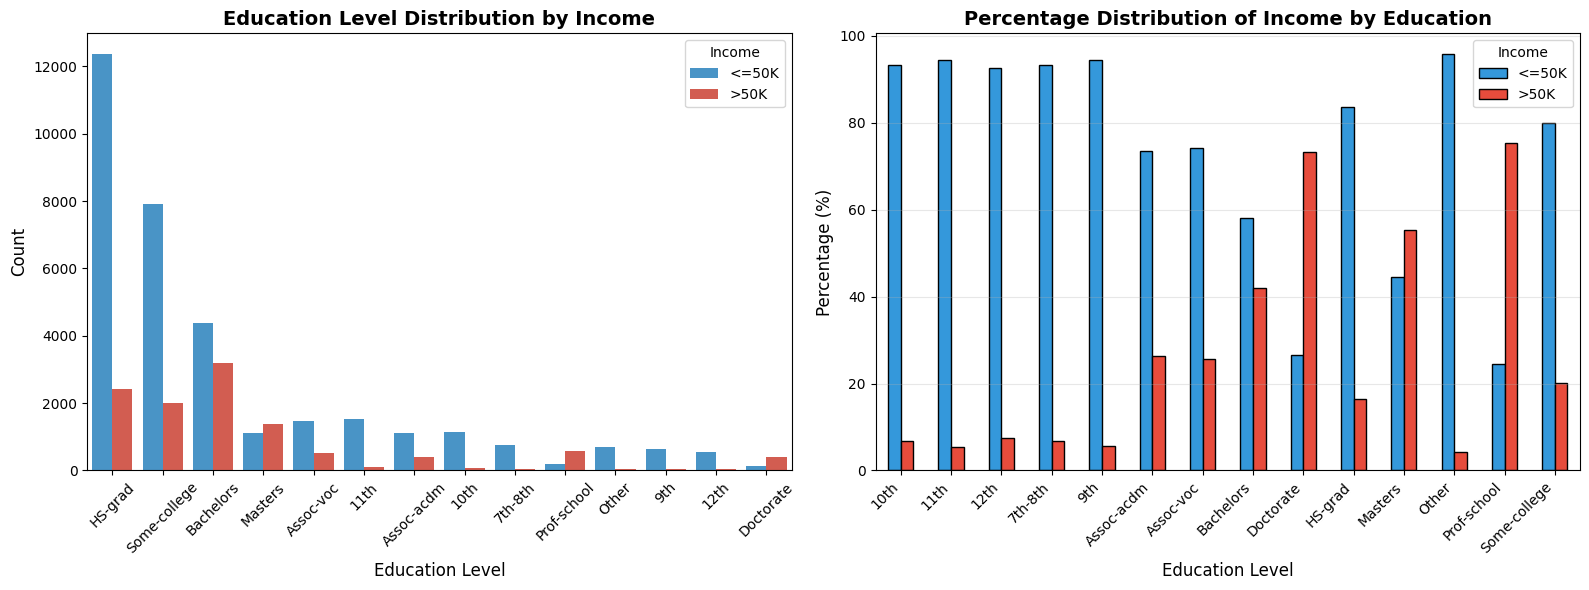


----------------------------------------
Key Insights:
----------------------------------------
- Highest earning potential: Prof-school (75.41% earn >50K)
- Lowest earning potential: Other (4.19% earn >50K)
- Education gap: 71.22 percentage points difference


In [97]:
# Education vs Income Analysis
print("-" * 70)
print("EDUCATION LEVEL VS INCOME ANALYSIS")
print("-" * 70)

# Create crosstab
education_income = pd.crosstab(df['education'], df['income'], normalize='index') * 100
education_income_counts = pd.crosstab(df['education'], df['income'])

print("\nPercentage earning >50K by education level:")
print(education_income['>50K'].sort_values(ascending=False))

# Visualize with grouped bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Count plot
education_order = df['education'].value_counts().index
sns.countplot(data=df, x='education', hue='income', order=education_order, 
              palette={'<=50K': '#3498db', '>50K': '#e74c3c'}, ax=ax1)
ax1.set_title('Education Level Distribution by Income', fontsize=14, fontweight='bold')
ax1.set_xlabel('Education Level', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(title='Income', loc='upper right')

# Percentage plot
education_income.plot(kind='bar', stacked=False, ax=ax2, 
                      color=['#3498db', '#e74c3c'], edgecolor='black')
ax2.set_title('Percentage Distribution of Income by Education', fontsize=14, fontweight='bold')
ax2.set_xlabel('Education Level', fontsize=12)
ax2.set_ylabel('Percentage (%)', fontsize=12)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.legend(title='Income', labels=['<=50K', '>50K'])
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical summary
print("\n" + "-" * 40)
print("Key Insights:")
print("-" * 40)
highest_income_edu = education_income['>50K'].idxmax()
highest_pct = education_income['>50K'].max()
print(f"- Highest earning potential: {highest_income_edu} ({highest_pct:.2f}% earn >50K)")
lowest_income_edu = education_income['>50K'].idxmin()
lowest_pct = education_income['>50K'].min()
print(f"- Lowest earning potential: {lowest_income_edu} ({lowest_pct:.2f}% earn >50K)")
print(f"- Education gap: {highest_pct - lowest_pct:.2f} percentage points difference")

## 3. Occupation and Workclass Trends

----------------------------------------------------------------------
OCCUPATION VS INCOME ANALYSIS
----------------------------------------------------------------------

Top 10 occupations with highest percentage earning >50K:
occupation
Exec-managerial      47.927115
Prof-specialty       45.027486
Protective-serv      31.454918
Tech-support         28.964059
Sales                26.904586
Craft-repair         22.527016
Transport-moving     20.639033
Adm-clerical         13.653603
Machine-op-inspct    12.268284
Farming-fishing      11.645227
Name: >50K, dtype: float64


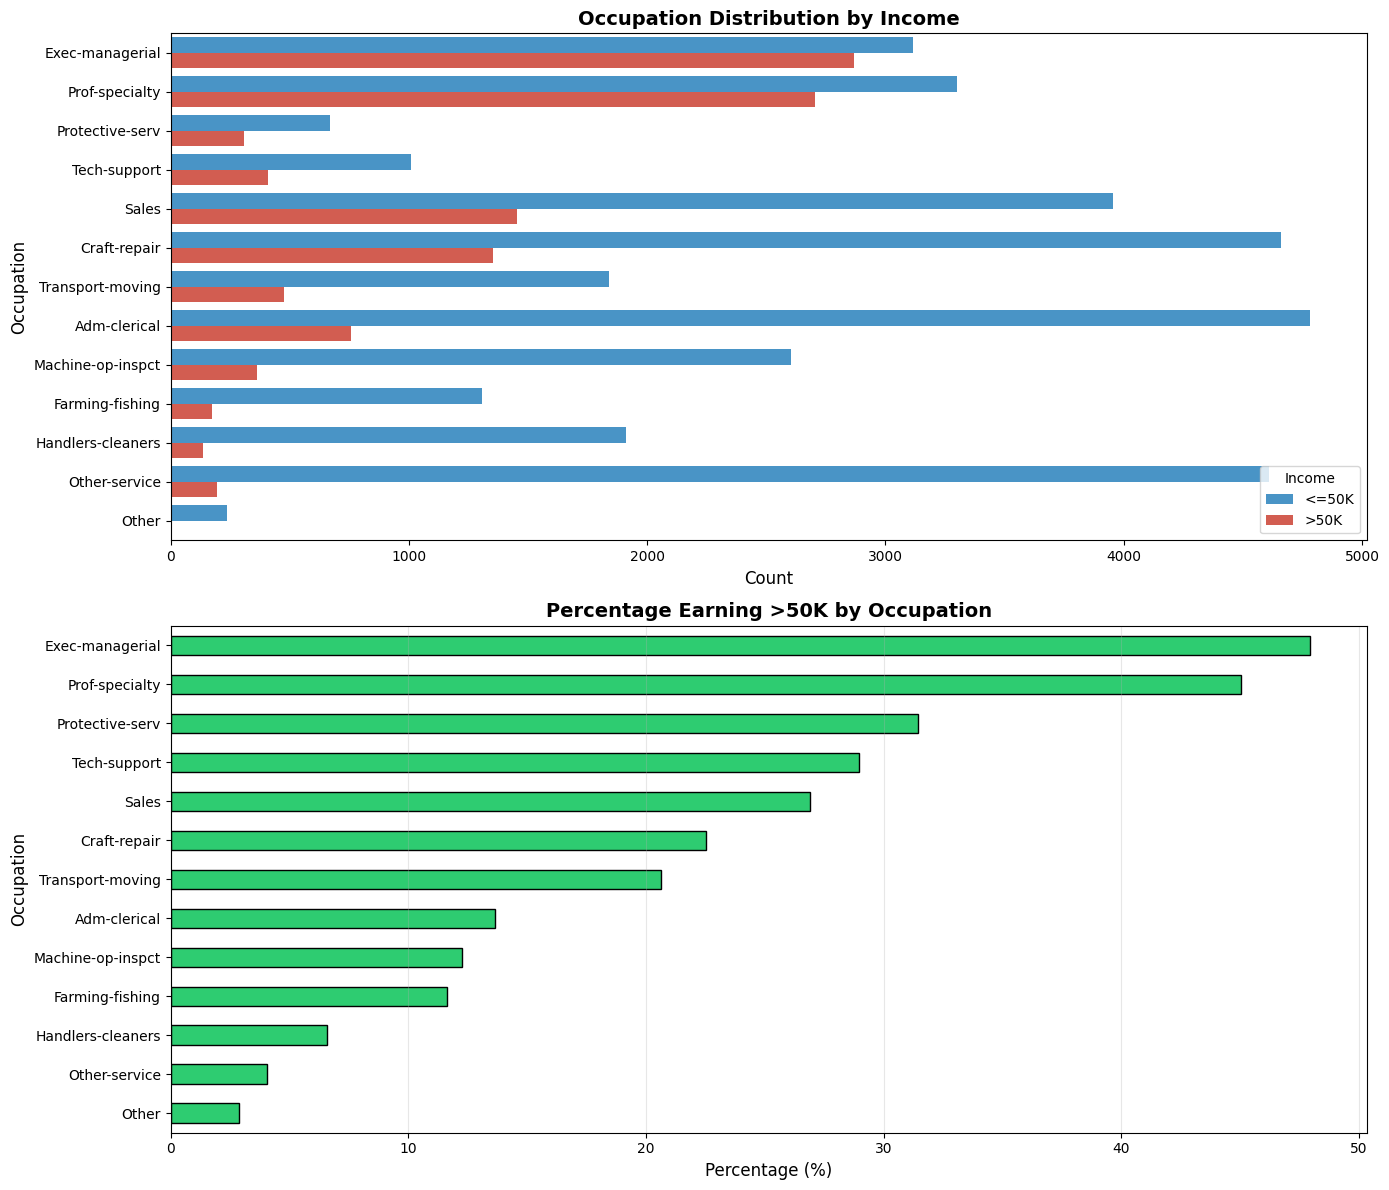

In [98]:
# Occupation vs Income Analysis
print("-" * 70)
print("OCCUPATION VS INCOME ANALYSIS")
print("-" * 70)

occupation_income = pd.crosstab(df['occupation'], df['income'], normalize='index') * 100

print("\nTop 10 occupations with highest percentage earning >50K:")
print(occupation_income['>50K'].sort_values(ascending=False).head(10))

# Visualize occupation trends
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Occupation income distribution
occupation_order = occupation_income['>50K'].sort_values(ascending=False).index
sns.countplot(data=df, y='occupation', hue='income', order=occupation_order,
              palette={'<=50K': '#3498db', '>50K': '#e74c3c'}, ax=axes[0])
axes[0].set_title('Occupation Distribution by Income', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count', fontsize=12)
axes[0].set_ylabel('Occupation', fontsize=12)
axes[0].legend(title='Income', loc='lower right')

# Percentage earning >50K by occupation
occupation_income['>50K'].sort_values().plot(kind='barh', ax=axes[1], 
                                              color='#2ecc71', edgecolor='black')
axes[1].set_title('Percentage Earning >50K by Occupation', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Percentage (%)', fontsize=12)
axes[1].set_ylabel('Occupation', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

----------------------------------------------------------------------
WORKCLASS VS INCOME ANALYSIS
----------------------------------------------------------------------

Percentage earning >50K by workclass:
workclass
Self-emp-inc        55.440729
Federal-gov         39.046942
Local-gov           29.516129
Self-emp-not-inc    27.905138
State-gov           26.721480
Private             21.781196
Other                9.523810
Name: >50K, dtype: float64


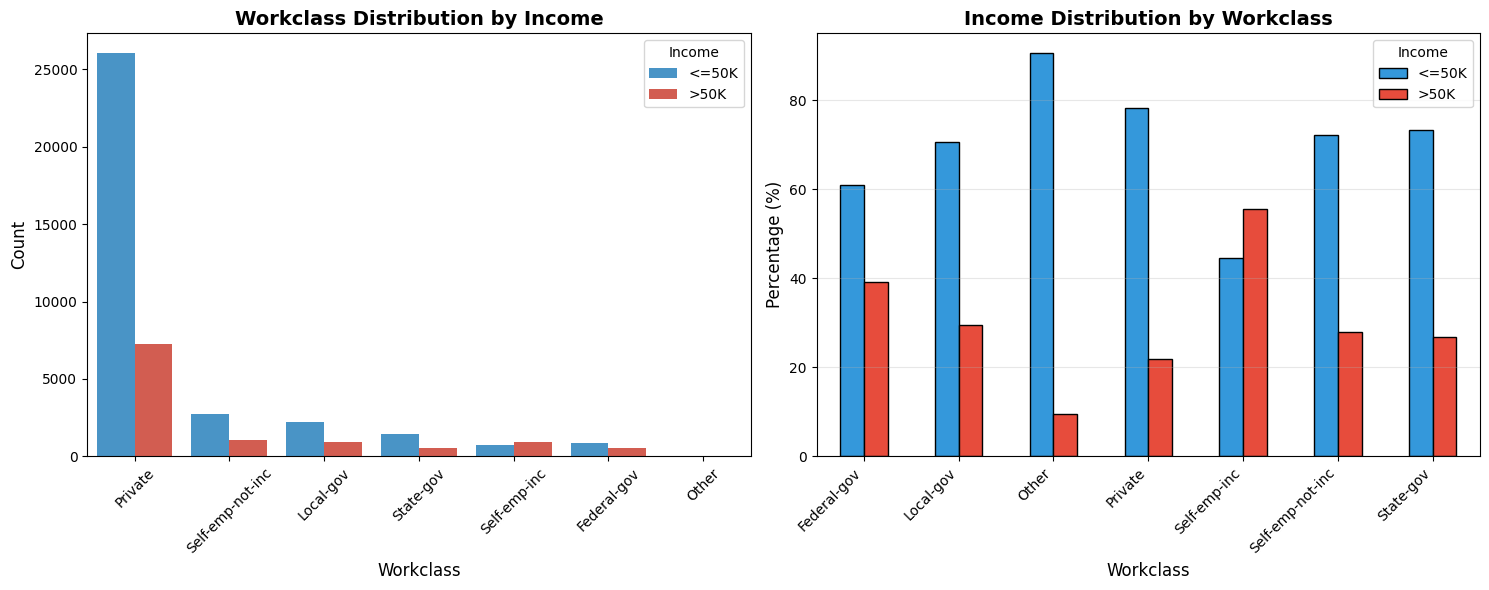


----------------------------------------------------------------------
Key Insights:
----------------------------------------------------------------------
- Best workclass: Self-emp-inc (55.44% earn >50K)
- Most common: Private (33,281 workers)


In [99]:
# Workclass vs Income Analysis
print("-" * 70)
print("WORKCLASS VS INCOME ANALYSIS")
print("-" * 70)

workclass_income = pd.crosstab(df['workclass'], df['income'], normalize='index') * 100

print("\nPercentage earning >50K by workclass:")
print(workclass_income['>50K'].sort_values(ascending=False))

# Visualize workclass trends
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Workclass distribution
workclass_order = df['workclass'].value_counts().index
sns.countplot(data=df, x='workclass', hue='income', order=workclass_order,
              palette={'<=50K': '#3498db', '>50K': '#e74c3c'}, ax=ax1)
ax1.set_title('Workclass Distribution by Income', fontsize=14, fontweight='bold')
ax1.set_xlabel('Workclass', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(title='Income')

# Percentage plot
workclass_income.plot(kind='bar', stacked=False, ax=ax2,
                      color=['#3498db', '#e74c3c'], edgecolor='black')
ax2.set_title('Income Distribution by Workclass', fontsize=14, fontweight='bold')
ax2.set_xlabel('Workclass', fontsize=12)
ax2.set_ylabel('Percentage (%)', fontsize=12)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.legend(title='Income', labels=['<=50K', '>50K'])
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "-" * 70)
print("Key Insights:")
print("-" * 70)
print(f"- Best workclass: {workclass_income['>50K'].idxmax()} ({workclass_income['>50K'].max():.2f}% earn >50K)")
print(f"- Most common: {df['workclass'].value_counts().idxmax()} ({df['workclass'].value_counts().max():,} workers)")

## 4. Age and Hours-per-Week Impact Analysis

----------------------------------------------------------------------
AGE VS INCOME ANALYSIS
----------------------------------------------------------------------

Age statistics by income level:
          count       mean        std   min   25%   50%   75%   max
income                                                             
<=50K   33988.0  36.753207  13.562497  17.0  26.0  34.0  46.0  90.0
>50K    11206.0  44.006782  10.341252  19.0  36.0  43.0  51.0  90.0


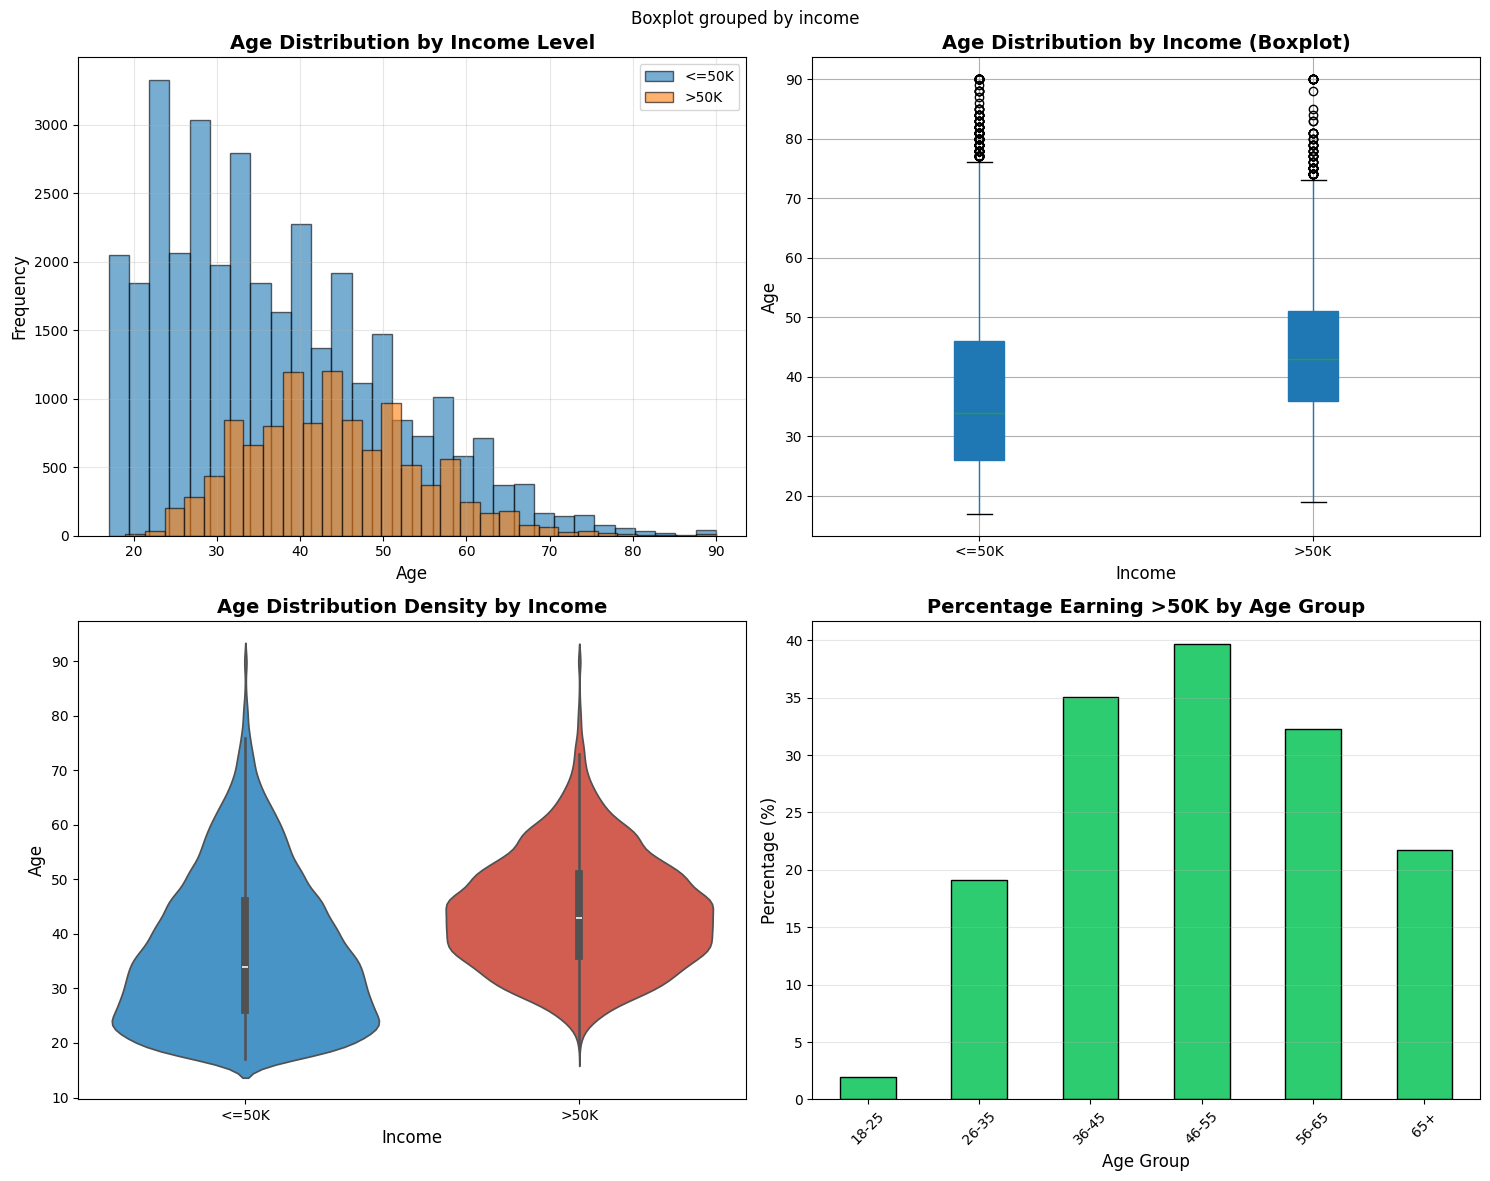


----------------------------------------------------------------------
Key Insights:
----------------------------------------------------------------------
 - Average age (<=50K): 36.8 years
 - Average age (>50K): 44.0 years
 - Peak earning age group: 46-55 (39.67% earn >50K)


In [100]:
# Age vs Income Analysis
print("-" * 70)
print("AGE VS INCOME ANALYSIS")
print("-" * 70)

# Statistical summary by income
print("\nAge statistics by income level:")
age_stats = df.groupby('income')['age'].describe()
print(age_stats)

# Visualize age distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Histogram
for income_level in df['income'].unique():
    subset = df[df['income'] == income_level]['age']
    axes[0, 0].hist(subset, bins=30, alpha=0.6, label=income_level, edgecolor='black')
axes[0, 0].set_title('Age Distribution by Income Level', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Age', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Box plot
df.boxplot(column='age', by='income', ax=axes[0, 1], patch_artist=True)
axes[0, 1].set_title('Age Distribution by Income (Boxplot)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Income', fontsize=12)
axes[0, 1].set_ylabel('Age', fontsize=12)
plt.sca(axes[0, 1])
plt.xticks([1, 2], df['income'].unique())

# Violin plot
sns.violinplot(data=df, x='income', y='age', palette={'<=50K': '#3498db', '>50K': '#e74c3c'}, ax=axes[1, 0])
axes[1, 0].set_title('Age Distribution Density by Income', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Income', fontsize=12)
axes[1, 0].set_ylabel('Age', fontsize=12)

# Age groups analysis
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 65, 100], 
                         labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])
age_group_income = pd.crosstab(df['age_group'], df['income'], normalize='index') * 100
age_group_income['>50K'].plot(kind='bar', ax=axes[1, 1], color='#2ecc71', edgecolor='black')
axes[1, 1].set_title('Percentage Earning >50K by Age Group', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Age Group', fontsize=12)
axes[1, 1].set_ylabel('Percentage (%)', fontsize=12)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "-" * 70)
print("Key Insights:")
print("-" * 70)
print(f" - Average age (<=50K): {df[df['income']=='<=50K']['age'].mean():.1f} years")
print(f" - Average age (>50K): {df[df['income']=='>50K']['age'].mean():.1f} years")
print(f" - Peak earning age group: {age_group_income['>50K'].idxmax()} ({age_group_income['>50K'].max():.2f}% earn >50K)")

----------------------------------------------------------------------
HOURS-PER-WEEK VS INCOME ANALYSIS
----------------------------------------------------------------------

Hours-per-week statistics by income level:
          count       mean        std  min   25%   50%   75%   max
income                                                            
<=50K   33988.0  39.375250  11.972898  1.0  37.0  40.0  40.0  99.0
>50K    11206.0  45.690791  10.798572  1.0  40.0  40.0  50.0  99.0


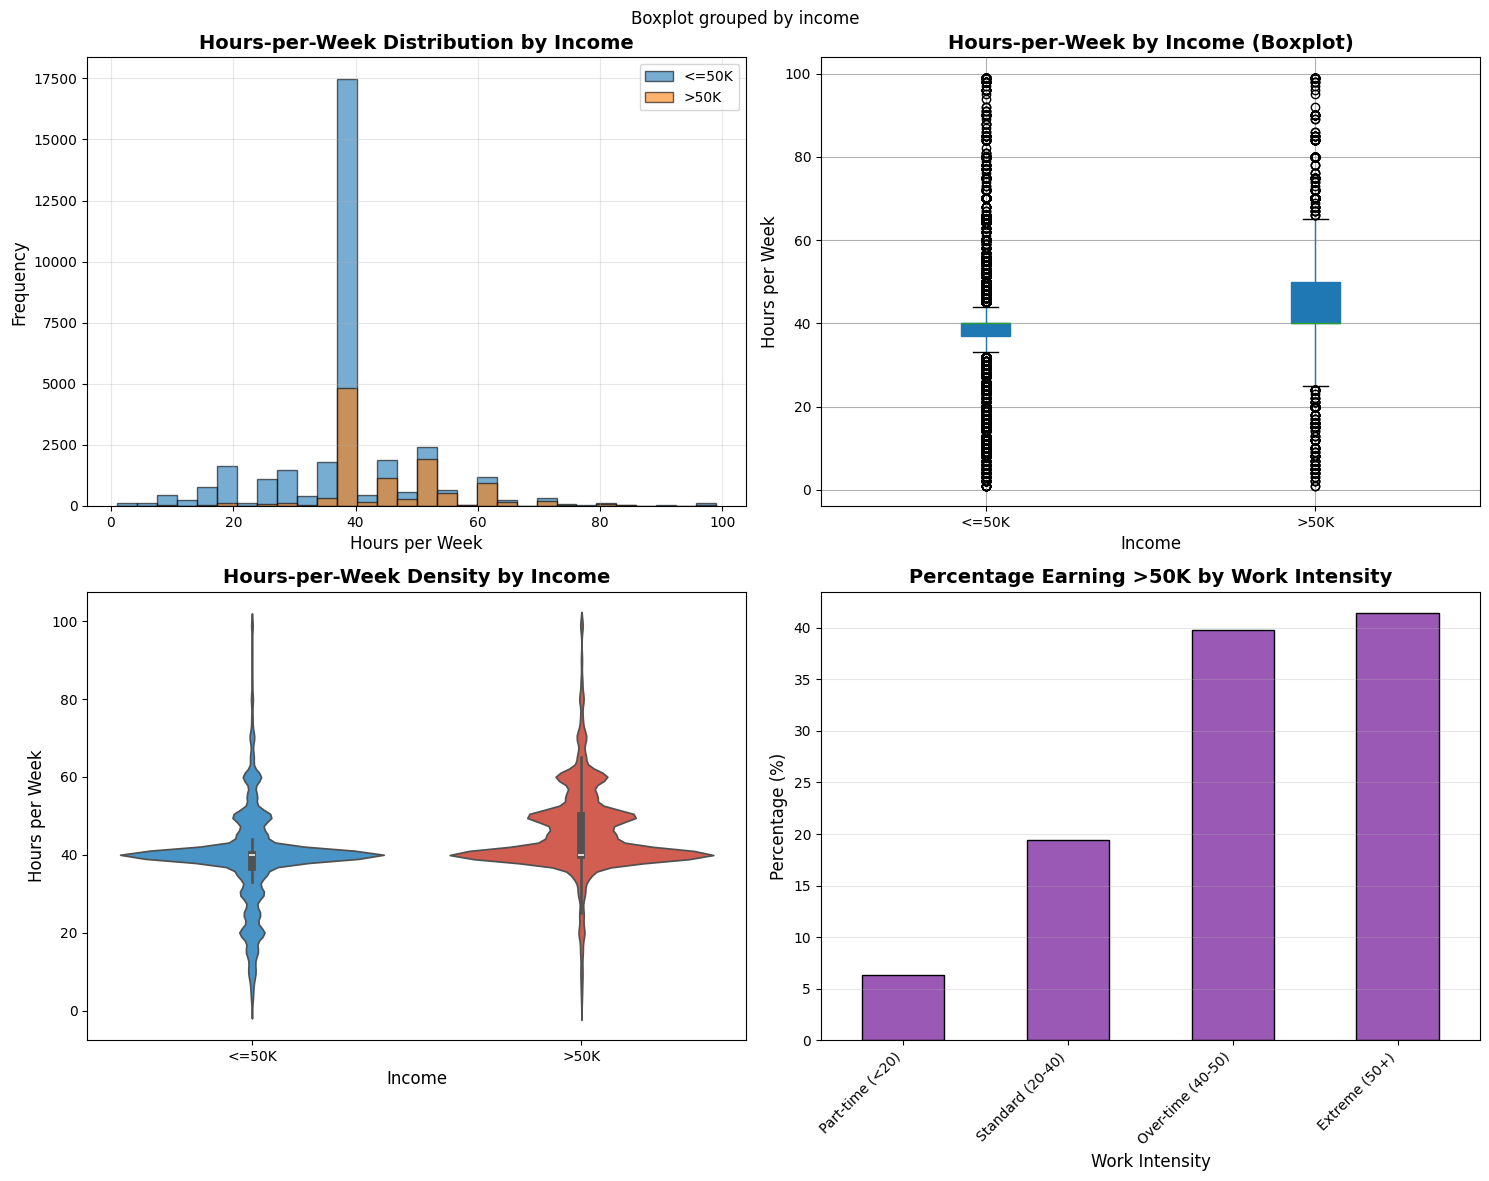


----------------------------------------------------------------------
Key Insights:
----------------------------------------------------------------------
- Average hours (<=50K): 39.4 hours/week
- Average hours (>50K): 45.7 hours/week
- Most profitable work intensity: Extreme (50+) (41.44% earn >50K)


In [101]:
# Hours-per-Week vs Income Analysis
print("-" * 70)
print("HOURS-PER-WEEK VS INCOME ANALYSIS")
print("-" * 70)

# Statistical summary
print("\nHours-per-week statistics by income level:")
hours_stats = df.groupby('income')['hours-per-week'].describe()
print(hours_stats)

# Visualize hours-per-week distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Histogram
for income_level in df['income'].unique():
    subset = df[df['income'] == income_level]['hours-per-week']
    axes[0, 0].hist(subset, bins=30, alpha=0.6, label=income_level, edgecolor='black')
axes[0, 0].set_title('Hours-per-Week Distribution by Income', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Hours per Week', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Box plot
df.boxplot(column='hours-per-week', by='income', ax=axes[0, 1], patch_artist=True)
axes[0, 1].set_title('Hours-per-Week by Income (Boxplot)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Income', fontsize=12)
axes[0, 1].set_ylabel('Hours per Week', fontsize=12)
plt.sca(axes[0, 1])
plt.xticks([1, 2], df['income'].unique())

# Violin plot
sns.violinplot(data=df, x='income', y='hours-per-week', 
               palette={'<=50K': '#3498db', '>50K': '#e74c3c'}, ax=axes[1, 0])
axes[1, 0].set_title('Hours-per-Week Density by Income', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Income', fontsize=12)
axes[1, 0].set_ylabel('Hours per Week', fontsize=12)

# Work intensity groups
df['work_intensity'] = pd.cut(df['hours-per-week'], 
                               bins=[0, 20, 40, 50, 100], 
                               labels=['Part-time (<20)', 'Standard (20-40)', 
                                      'Over-time (40-50)', 'Extreme (50+)'])
work_intensity_income = pd.crosstab(df['work_intensity'], df['income'], normalize='index') * 100
work_intensity_income['>50K'].plot(kind='bar', ax=axes[1, 1], color='#9b59b6', edgecolor='black')
axes[1, 1].set_title('Percentage Earning >50K by Work Intensity', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Work Intensity', fontsize=12)
axes[1, 1].set_ylabel('Percentage (%)', fontsize=12)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "-" * 70)
print("Key Insights:")
print("-" * 70)
print(f"- Average hours (<=50K): {df[df['income']=='<=50K']['hours-per-week'].mean():.1f} hours/week")
print(f"- Average hours (>50K): {df[df['income']=='>50K']['hours-per-week'].mean():.1f} hours/week")
print(f"- Most profitable work intensity: {work_intensity_income['>50K'].idxmax()} ({work_intensity_income['>50K'].max():.2f}% earn >50K)")

## 5. Advanced Correlation Analysis

----------------------------------------------------------------------
CORRELATION ANALYSIS
----------------------------------------------------------------------

Correlation Matrix:
                     age    fnlwgt  education-num  capital-gain  capital-loss  \
age             1.000000 -0.075613       0.037430      0.079679      0.059316   
fnlwgt         -0.075613  1.000000      -0.042033     -0.004116     -0.004357   
education-num   0.037430 -0.042033       1.000000      0.126951      0.081709   
capital-gain    0.079679 -0.004116       0.126951      1.000000     -0.032123   
capital-loss    0.059316 -0.004357       0.081709     -0.032123      1.000000   
hours-per-week  0.101735 -0.018680       0.146401      0.083875      0.054159   

                hours-per-week  
age                   0.101735  
fnlwgt               -0.018680  
education-num         0.146401  
capital-gain          0.083875  
capital-loss          0.054159  
hours-per-week        1.000000  


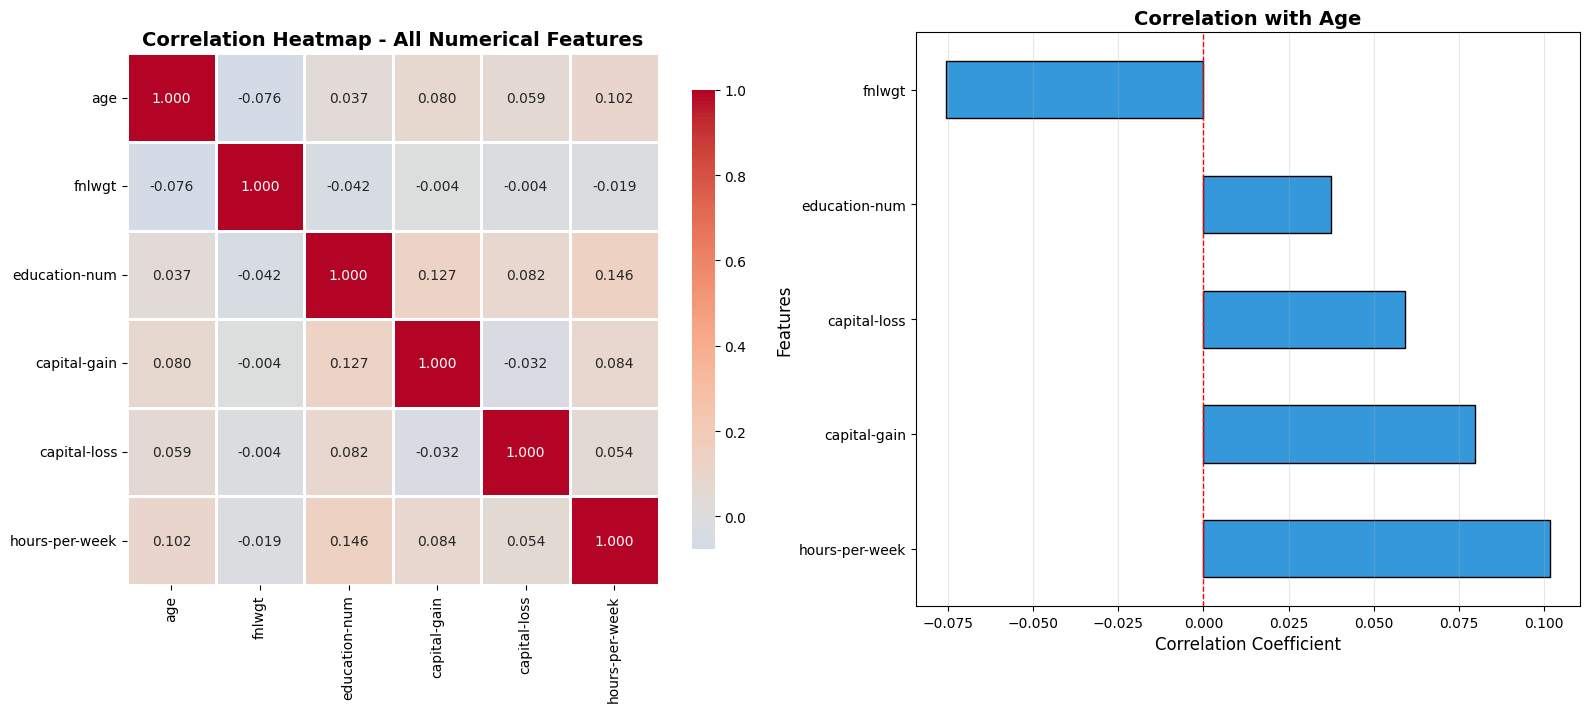


Strong Correlations (|r| > 0.3):
No strong correlations found (|r| > 0.3)


In [102]:
# Enhanced Correlation Analysis
print("-" * 70)
print("CORRELATION ANALYSIS")
print("-" * 70)

# Get numerical columns
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Calculate correlation matrix
correlation_matrix = df[numerical_features].corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)

# Create comprehensive correlation visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Heatmap with annotations
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=2, cbar_kws={"shrink": 0.8}, 
            fmt='.3f', ax=axes[0])
axes[0].set_title('Correlation Heatmap - All Numerical Features', 
                  fontsize=14, fontweight='bold')

# Correlation with specific feature (e.g., age)
age_corr = correlation_matrix['age'].sort_values(ascending=False)
age_corr.drop('age').plot(kind='barh', ax=axes[1], color='#3498db', edgecolor='black')
axes[1].set_title('Correlation with Age', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Correlation Coefficient', fontsize=12)
axes[1].set_ylabel('Features', fontsize=12)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Identify strong correlations
print("\n" + "=" * 70)
print("Strong Correlations (|r| > 0.3):")
print("=" * 70)
strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.3:
            strong_corr.append((correlation_matrix.columns[i], 
                               correlation_matrix.columns[j], 
                               correlation_matrix.iloc[i, j]))

if strong_corr:
    for feat1, feat2, corr_val in sorted(strong_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"• {feat1} ↔ {feat2}: {corr_val:.3f}")
else:
    print("No strong correlations found (|r| > 0.3)")

## 6. Comprehensive Boxplot Analysis

----------------------------------------------------------------------
BOXPLOT ANALYSIS - NUMERICAL FEATURES BY INCOME
----------------------------------------------------------------------


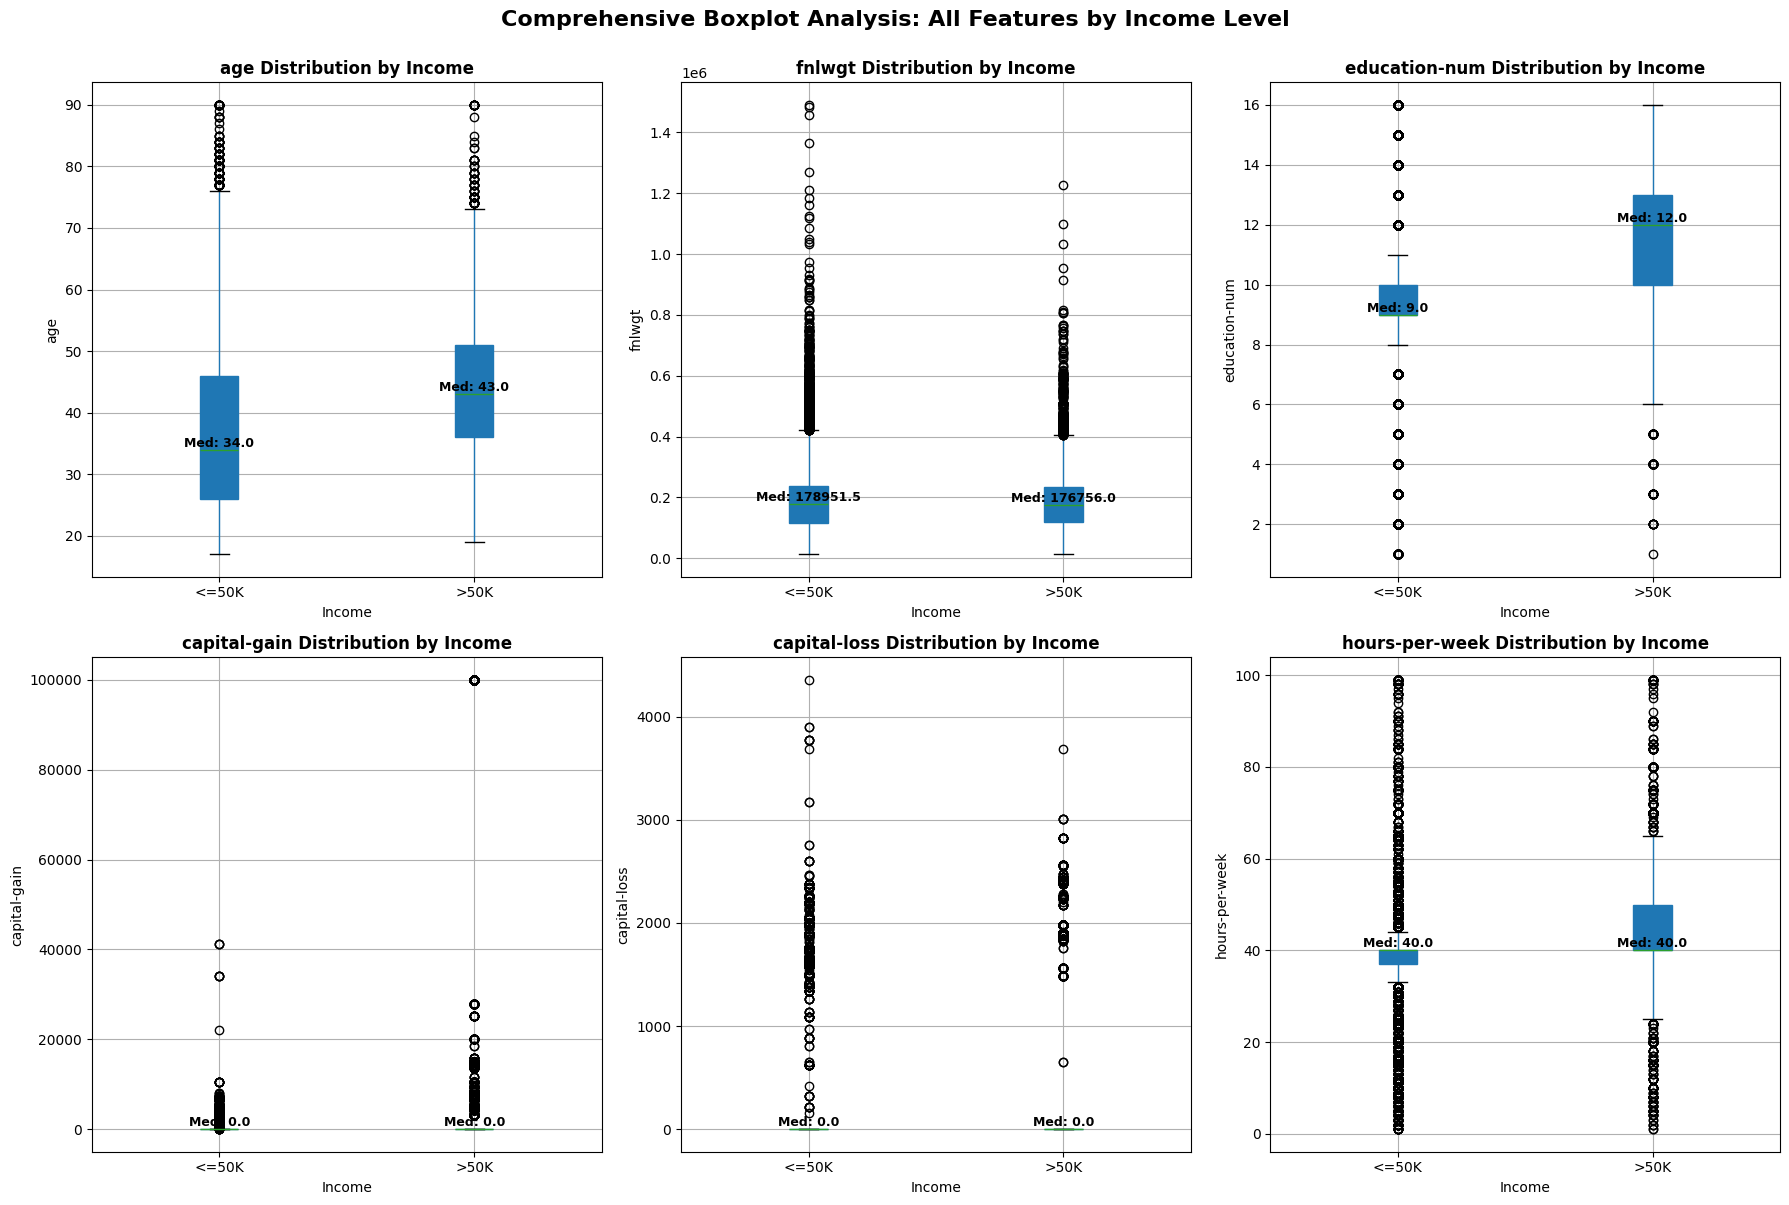


Median Comparison by Income Level:
----------------------------------------------------------------------
age:
  <=50K median: 34.00
  >50K median: 43.00
  Difference: 9.00 (+26.5%)

fnlwgt:
  <=50K median: 178951.50
  >50K median: 176756.00
  Difference: -2195.50 (-1.2%)

education-num:
  <=50K median: 9.00
  >50K median: 12.00
  Difference: 3.00 (+33.3%)

capital-gain:
  <=50K median: 0.00
  >50K median: 0.00
  Difference: 0.00 (+0.0%)

capital-loss:
  <=50K median: 0.00
  >50K median: 0.00
  Difference: 0.00 (+0.0%)

hours-per-week:
  <=50K median: 40.00
  >50K median: 40.00
  Difference: 0.00 (+0.0%)

hours-per-week:
  <=50K median: 40.00
  >50K median: 40.00
  Difference: 0.00 (+0.0%)



In [103]:
# Comprehensive boxplot analysis for all numerical features by income
print("-" * 70)
print("BOXPLOT ANALYSIS - NUMERICAL FEATURES BY INCOME")
print("-" * 70)

numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Create boxplots for each numerical feature split by income
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

colors = {'<=50K': '#3498db', '>50K': '#e74c3c'}

for idx, feature in enumerate(numerical_features):
    if idx < len(axes):
        # Create boxplot
        df.boxplot(column=feature, by='income', ax=axes[idx], patch_artist=True)
        
        # Customize
        axes[idx].set_title(f'{feature} Distribution by Income', 
                           fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Income', fontsize=10)
        axes[idx].set_ylabel(feature, fontsize=10)
        
        # Remove the automatic title
        plt.sca(axes[idx])
        plt.xticks([1, 2], df['income'].unique())
        
        # Add median values as text
        for i, income_level in enumerate(df['income'].unique(), 1):
            median_val = df[df['income'] == income_level][feature].median()
            axes[idx].text(i, median_val, f'Med: {median_val:.1f}', 
                          ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.suptitle('Comprehensive Boxplot Analysis: All Features by Income Level', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Statistical comparison
print("\nMedian Comparison by Income Level:")
print("-" * 70)
for feature in numerical_features:
    median_low = df[df['income'] == '<=50K'][feature].median()
    median_high = df[df['income'] == '>50K'][feature].median()
    diff = median_high - median_low
    pct_diff = (diff / median_low * 100) if median_low != 0 else 0
    print(f"{feature}:")
    print(f"  <=50K median: {median_low:.2f}")
    print(f"  >50K median: {median_high:.2f}")
    print(f"  Difference: {diff:.2f} ({pct_diff:+.1f}%)")
    print()

## 7. Additional Insights - Demographics and Relationships

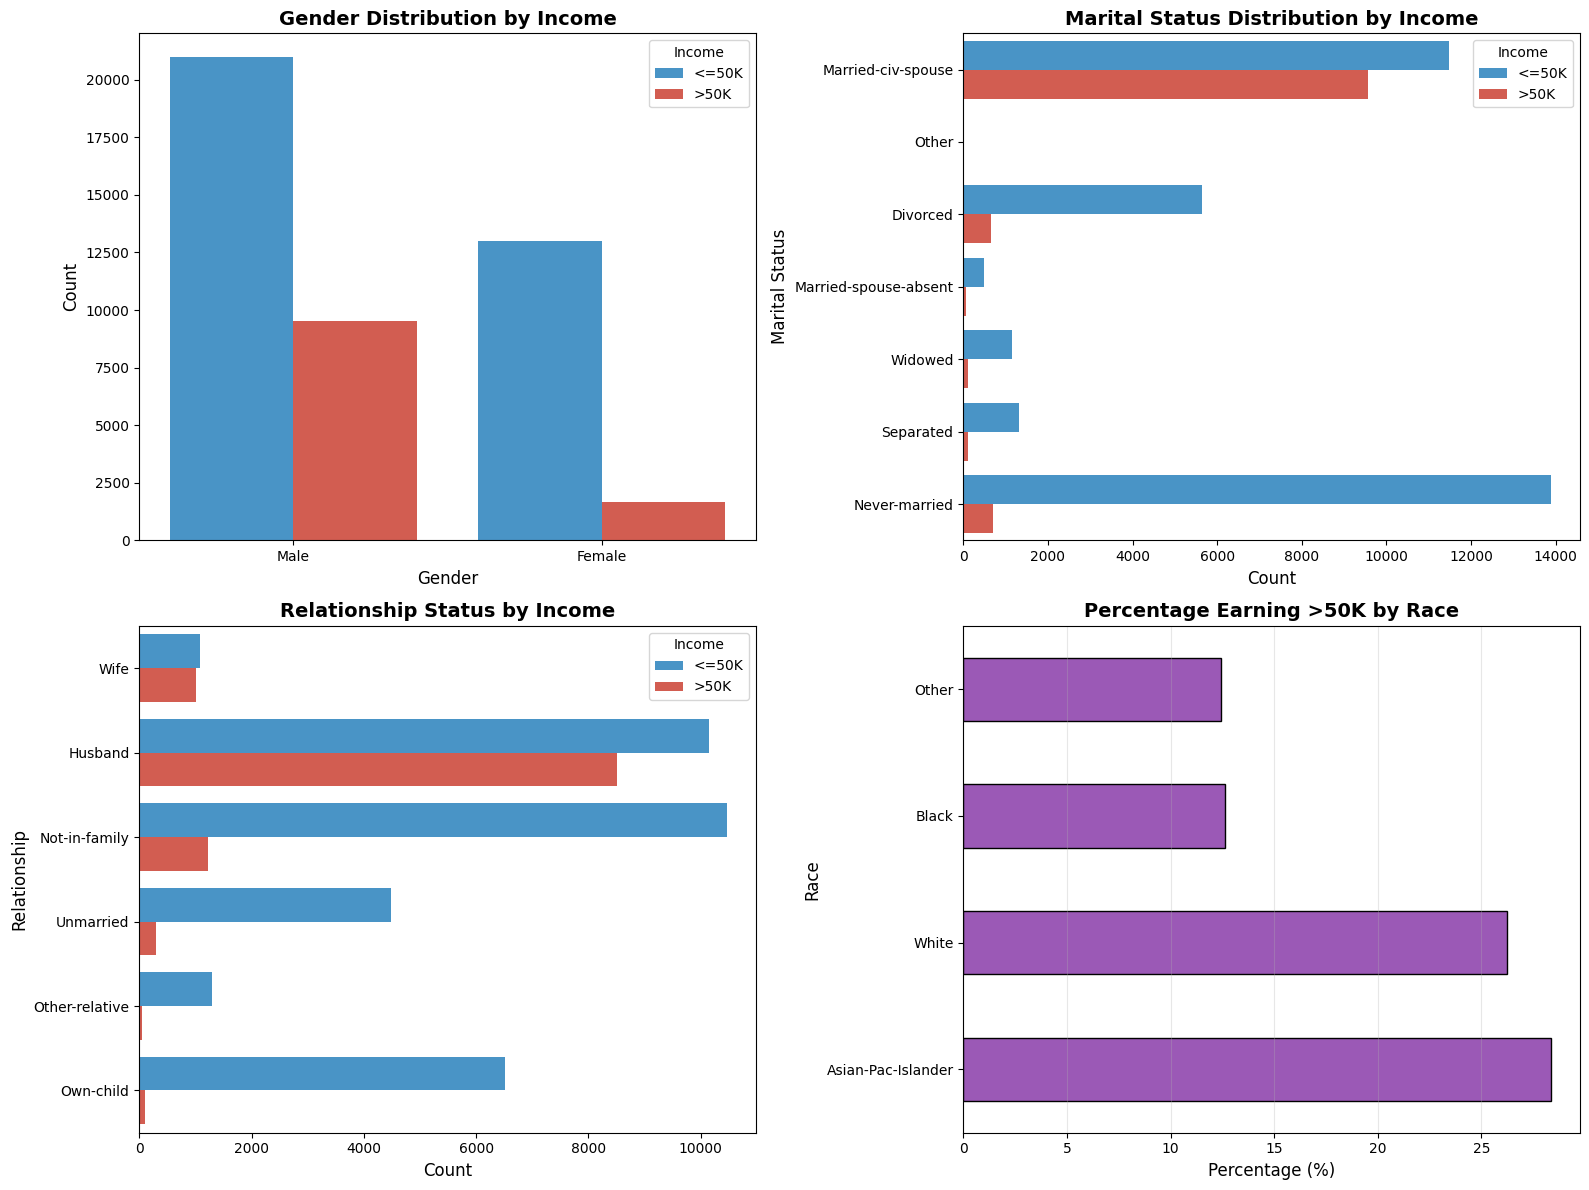

----------------------------------------------------------------------
DEMOGRAPHIC INSIGHTS
----------------------------------------------------------------------

Gender earnings gap:
- Male earning >50K: 31.26%
- Female earning >50K: 11.37%

Marital status with highest income:
- Married-civ-spouse: 45.43% earn >50K

Relationship status with highest income:
- Wife: 48.59% earn >50K


In [104]:
# Gender, Marital Status, and Relationship Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gender vs Income
gender_income = pd.crosstab(df['sex'], df['income'], normalize='index') * 100
sns.countplot(data=df, x='sex', hue='income', palette={'<=50K': '#3498db', '>50K': '#e74c3c'}, ax=axes[0, 0])
axes[0, 0].set_title('Gender Distribution by Income', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Gender', fontsize=12)
axes[0, 0].set_ylabel('Count', fontsize=12)
axes[0, 0].legend(title='Income')

# Marital Status vs Income
marital_income = pd.crosstab(df['marital-status'], df['income'], normalize='index') * 100
marital_order = marital_income['>50K'].sort_values(ascending=False).index
sns.countplot(data=df, y='marital-status', hue='income', order=marital_order,
              palette={'<=50K': '#3498db', '>50K': '#e74c3c'}, ax=axes[0, 1])
axes[0, 1].set_title('Marital Status Distribution by Income', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Count', fontsize=12)
axes[0, 1].set_ylabel('Marital Status', fontsize=12)
axes[0, 1].legend(title='Income')

# Relationship vs Income
relationship_income = pd.crosstab(df['relationship'], df['income'], normalize='index') * 100
relationship_order = relationship_income['>50K'].sort_values(ascending=False).index
sns.countplot(data=df, y='relationship', hue='income', order=relationship_order,
              palette={'<=50K': '#3498db', '>50K': '#e74c3c'}, ax=axes[1, 0])
axes[1, 0].set_title('Relationship Status by Income', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Count', fontsize=12)
axes[1, 0].set_ylabel('Relationship', fontsize=12)
axes[1, 0].legend(title='Income')

# Race vs Income
race_income = pd.crosstab(df['race'], df['income'], normalize='index') * 100
race_order = race_income['>50K'].sort_values(ascending=False).index
race_income['>50K'].loc[race_order].plot(kind='barh', ax=axes[1, 1], color='#9b59b6', edgecolor='black')
axes[1, 1].set_title('Percentage Earning >50K by Race', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Percentage (%)', fontsize=12)
axes[1, 1].set_ylabel('Race', fontsize=12)
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print insights
print("-" * 70)
print("DEMOGRAPHIC INSIGHTS")
print("-" * 70)
print(f"\nGender earnings gap:")
print(f"- Male earning >50K: {gender_income.loc['Male', '>50K']:.2f}%")
print(f"- Female earning >50K: {gender_income.loc['Female', '>50K']:.2f}%")
print(f"\nMarital status with highest income:")
print(f"- {marital_income['>50K'].idxmax()}: {marital_income['>50K'].max():.2f}% earn >50K")
print(f"\nRelationship status with highest income:")
print(f"- {relationship_income['>50K'].idxmax()}: {relationship_income['>50K'].max():.2f}% earn >50K")

## 8. EDA Summary and Key Findings

In [105]:
# Comprehensive EDA Summary
print("-" * 80)
print(" " * 20 + "EXPLORATORY DATA ANALYSIS SUMMARY")
print("-" * 80)

print("\n DATASET OVERVIEW:")
print(f"   • Total records: {len(df):,}")
print(f"   • Features: {len(df.columns)}")
print(f"   • Numerical features: {len(df.select_dtypes(include=['int64', 'float64']).columns)}")
print(f"   • Categorical features: {len(df.select_dtypes(include=['object']).columns)}")

print("\n INCOME DISTRIBUTION:")
income_dist = df['income'].value_counts(normalize=True) * 100
print(f"   • <=50K: {income_dist['<=50K']:.2f}%")
print(f"   • >50K: {income_dist['>50K']:.2f}%")
print(f"   • Class imbalance ratio: {income_dist.max()/income_dist.min():.2f}:1")

print("\n EDUCATION IMPACT:")
education_income = pd.crosstab(df['education'], df['income'], normalize='index') * 100
top_edu = education_income['>50K'].idxmax()
print(f"   • Highest earning education: {top_edu} ({education_income.loc[top_edu, '>50K']:.2f}% earn >50K)")
print(f"   • Education strongly correlates with higher income")

print("\n OCCUPATION INSIGHTS:")
occupation_income = pd.crosstab(df['occupation'], df['income'], normalize='index') * 100
top_occ = occupation_income['>50K'].idxmax()
print(f"   • Highest earning occupation: {top_occ} ({occupation_income.loc[top_occ, '>50K']:.2f}% earn >50K)")
print(f"   • Most common occupation: {df['occupation'].value_counts().idxmax()}")

print("\n WORKCLASS PATTERNS:")
workclass_income = pd.crosstab(df['workclass'], df['income'], normalize='index') * 100
top_work = workclass_income['>50K'].idxmax()
print(f"   • Best workclass: {top_work} ({workclass_income.loc[top_work, '>50K']:.2f}% earn >50K)")

print("\n AGE ANALYSIS:")
print(f"   • Average age (<=50K): {df[df['income']=='<=50K']['age'].mean():.1f} years")
print(f"   • Average age (>50K): {df[df['income']=='>50K']['age'].mean():.1f} years")
print(f"   • Age range: {df['age'].min()}-{df['age'].max()} years")

print("\n WORK HOURS:")
print(f"   • Average hours (<=50K): {df[df['income']=='<=50K']['hours-per-week'].mean():.1f} hrs/week")
print(f"   • Average hours (>50K): {df[df['income']=='>50K']['hours-per-week'].mean():.1f} hrs/week")
print(f"   • Higher earners work {df[df['income']=='>50K']['hours-per-week'].mean() - df[df['income']=='<=50K']['hours-per-week'].mean():.1f} more hours/week")

print("\n DEMOGRAPHICS:")
gender_income = pd.crosstab(df['sex'], df['income'], normalize='index') * 100
print(f"   • Male earning >50K: {gender_income.loc['Male', '>50K']:.2f}%")
print(f"   • Female earning >50K: {gender_income.loc['Female', '>50K']:.2f}%")
marital_income = pd.crosstab(df['marital-status'], df['income'], normalize='index') * 100
top_marital = marital_income['>50K'].idxmax()
print(f"   • Best marital status: {top_marital} ({marital_income.loc[top_marital, '>50K']:.2f}% earn >50K)")

print("\n KEY PREDICTIVE FEATURES:")
print("   Based on the analysis, the most important features for predicting income are:")
print("   1. Education level (strong positive correlation)")
print("   2. Occupation type (significant variation)")
print("   3. Age (older individuals tend to earn more)")
print("   4. Hours per week (longer hours correlate with higher income)")
print("   5. Marital status (married individuals earn more)")
print("   6. Workclass (self-employed/government workers earn more)")

print("\n" + "-" * 80)
print("EDA COMPLETE - Ready for Feature Engineering and Modeling")
print("-" * 80)

--------------------------------------------------------------------------------
                    EXPLORATORY DATA ANALYSIS SUMMARY
--------------------------------------------------------------------------------

 DATASET OVERVIEW:
   • Total records: 45,194
   • Features: 17
   • Numerical features: 6
   • Categorical features: 9

 INCOME DISTRIBUTION:
   • <=50K: 75.20%
   • >50K: 24.80%
   • Class imbalance ratio: 3.03:1

 EDUCATION IMPACT:
   • Highest earning education: Prof-school (75.41% earn >50K)
   • Education strongly correlates with higher income

 OCCUPATION INSIGHTS:
   • Highest earning occupation: Exec-managerial (47.93% earn >50K)
   • Most common occupation: Craft-repair

 WORKCLASS PATTERNS:
   • Best workclass: Self-emp-inc (55.44% earn >50K)

 AGE ANALYSIS:
   • Average age (<=50K): 36.8 years
   • Average age (>50K): 44.0 years
   • Age range: 17-90 years

 WORK HOURS:
   • Best workclass: Self-emp-inc (55.44% earn >50K)

 AGE ANALYSIS:
   • Average age (<=50K